In [1]:
# import packages
import pandas as pd
import numpy as np
from typing import Union

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import arviz as az
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.1
numpy: 2.4.3
pymc: 5.28.2
sklearn: 1.8.0
pytensor: 2.38.2
arviz: 0.23.4
arviz_plots: 1.0.0


In [2]:
# import data
df = pd.read_csv('data/bat_speed_model_data.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bips,ev90,latent_ev90,latent_ev90_std,swings,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,model_bat_speed_std
0,405395,2021,Mar/Apr,0,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,63.0,106.16,106.177,0.564,NaN,NaN,72.319750,1.638141,72.319750,1.638141
1,405395,2021,May,1,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,41.0,108.40,107.838,0.686,NaN,NaN,73.605947,1.653297,73.605947,1.653297
2,405395,2021,Jun,2,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,41.0,103.90,104.412,0.686,NaN,NaN,70.952174,1.654974,70.952174,1.654974
3,405395,2021,Jul,3,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,44.0,105.79,105.652,0.666,NaN,NaN,71.908811,1.658140,71.908811,1.658140
4,405395,2021,Aug,4,Albert Pujols (405395),Albert Pujols,Albert,Pujols,R,1980-01-16,...,19.0,105.56,105.493,0.937,NaN,NaN,71.774109,1.728959,71.774109,1.728959


In [ ]:
# df['country_recode'] = np.where(df['country2'].isin(['East North Central, USA', 'East South Central, USA', 'West South Central, USA', 'West North Central, USA']), 'Central, USA', df['country2'])
# df['country_recode'] = np.where(df['country_recode'].isin(['Pacific North West, USA', 'Mountain, USA']), 'West, USA', df['country_recode'])
# df['country_recode'] = np.where(df['country_recode'].isin(['New England, USA', 'South Mid-Atlantic, USA', 'Virginias, USA', 'Mid-Atlantic, USA', 'South Atlantic, USA', ]), 'East, USA', df['country_recode'])
# df['country_recode'] = np.where(df['country_recode'].isin(['Europe', 'Canada', 'Puerto Rico', 'Pacific']), 'Other', df['country_recode'])
# df['country_recode'].value_counts()

# df['split_column'] = df['position'] + '_' + df['country_recode']

# # rip off 2026 to help forecast
# forecast_df = df.loc[df['year'] == 2026].reset_index(drop=True)
# df = df.loc[df['year'] < 2026].reset_index(drop=True)

# # define the train and test sets, split by bam_id, stratified by position and country
# player_df = df[['bam_id', 'position', 'country_recode']].drop_duplicates().reset_index(drop=True)
# player_df['split_column'] = player_df['position'] + '_' + player_df['country_recode']
# # remove players with unique split_column values, only 1 player in that position and country
# players_removed = player_df['split_column'].value_counts()[player_df['split_column'].value_counts() == 1].index.tolist()
# players_add_back = player_df[player_df['split_column'].isin(players_removed)]
# player_df = player_df[~player_df['split_column'].isin(players_removed)]

# # split
# train_players, test_players = train_test_split(player_df, test_size=0.25, random_state=RANDOM_SEED, stratify=player_df['split_column'])

# # create the train and test sets
# train_players = pd.concat([train_players, players_add_back], ignore_index=True)
# train_df = df[df['bam_id'].isin(train_players['bam_id'])].reset_index(drop=True)
# test_df = df[df['bam_id'].isin(test_players['bam_id'])].reset_index(drop=True)

# print(train_df.shape)
# print(test_df.shape)
# print(len(players_removed))

# # who got removed from the split?
# print(df.loc[df['split_column'].isin(players_removed)]['full'].value_counts())

# # scale age
# train_age = train_df['age'].mean()
# train_age_std = train_df['age'].std()
# train_df['age_z'] =  (train_df['age'] - train_age) / train_age_std
# test_df['age_z'] =  (test_df['age'] - train_age) / train_age_std

# # scale bat_speed
# train_bat_speed_mean = train_df['model_bat_speed'].mean()
# train_bat_speed_std = train_df['model_bat_speed'].std()

# train_df['model_bat_speed_z'] = (train_df['model_bat_speed'] - train_bat_speed_mean) / train_bat_speed_std
# test_df['model_bat_speed_z'] = (test_df['model_bat_speed'] - train_bat_speed_mean) / train_bat_speed_std

# train_df['model_bat_speed_std_z'] = train_df['model_bat_speed_std'] / train_bat_speed_std
# test_df['model_bat_speed_std_z'] = test_df['model_bat_speed_std'] / train_bat_speed_std

# train_df.tail()

# # init values
# train_age = train_df['age_z'].values
# train_age_sq = train_age**2
# train_bat_speed_z = train_df['model_bat_speed_z'].values
# train_bat_speed_std_z = train_df['model_bat_speed_std_z'].values

country_recode
Central, USA          2814
East, USA             2650
California, USA       2500
Dominican Republic    1551
Venezuela             1474
Latin America         1136
Florida, USA          1104
West, USA             1004
Other                  970
Name: count, dtype: int64

In [3]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        az.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [4]:
# standardize age
age_mean = np.mean(df['age'])
age_std = np.std(df['age'])
df['age_z'] = (df['age'] - age_mean)/age_std
age_z = df['age_z'].values

# standardize bat speed
bat_speed_mean = np.mean(df['model_bat_speed'])
bat_speed_std = np.std(df['model_bat_speed'])
df['model_bat_speed_z'] = (df['model_bat_speed'] - bat_speed_mean)/bat_speed_std
bat_speed_z = df['model_bat_speed_z'].values

# rescale the sigma of bat speed
df['model_bat_speed_std_z'] = df['model_bat_speed_std']/bat_speed_std
bat_speed_sigma = df['model_bat_speed_std_z'].values
df.tail(5)

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,latent_ev90_std,swings,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,model_bat_speed_std,age_z,model_bat_speed_z,model_bat_speed_std_z
15198,810938,2025,Jul,27,Ben Williamson (810938),Ben Williamson,Ben,Williamson,R,2000-11-05,...,0.572,133.0,67.998496,69.199773,1.627090,67.998496,0.243937,-1.065253,-0.758006,0.085618
15199,810938,2026,Mar/Apr,30,Ben Williamson (810938),Ben Williamson,Ben,Williamson,R,2000-11-05,...,0.585,126.0,69.579365,68.847026,1.631825,69.579365,0.250622,-0.858485,-0.203144,0.087965
15200,810938,2026,May,31,Ben Williamson (810938),Ben Williamson,Ben,Williamson,R,2000-11-05,...,0.869,61.0,69.222951,72.067386,1.704706,69.222951,0.360196,-0.835846,-0.328240,0.126424
15201,814439,2026,May,31,Ryan Waldschmidt (814439),Ryan Waldschmidt,Ryan,Waldschmidt,R,2002-10-07,...,0.750,95.0,71.868421,68.641005,1.672160,71.868421,0.288630,-1.364841,0.600281,0.101305
15202,823550,2026,May,31,Sung-Mun Song (823550),Sung-Mun Song,Sung-Mun,Song,L,1996-08-29,...,1.250,38.0,70.368421,68.514746,1.847043,70.368421,0.456365,0.317982,0.073803,0.160177


In [5]:
# now add player indexes in terms, varying intercept
# first use handy index function
def define_index(data: pd.DataFrame, label: str, plus_one:bool=True) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values
    
    if plus_one:
        index_vals = index_vals + 1
    return index_vals, lookup

In [6]:
# apply said index
df['player_full_id'] = df['full'] + " (" + df['bam_id'].astype(str) + ")"
player_name_list = pd.unique(df['player_full_id']).tolist()
df["player_idx"], player_lookup = define_index(df, "player_full_id", plus_one=False)
player_index_vals = df['player_idx'].values.astype("int32")
n_obs = len(df)

In [ ]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_z), np.max(age_z)],
    lengthscale_range=[1, 3],
    cov_func="matern32",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 46, c: 4.25


In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# Matern 52 kernel
# pymc model
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_index_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.Gamma("ls", alpha=1.0, beta=1.0)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    target = pm.Normal("target", mu=theta, sigma=sigma_data, observed=bat_speed_z)

Sampling: [eta, f_hsgp_coeffs, ls]


Text(0.5, 1.0, 'Prior Predictive GP Draws')

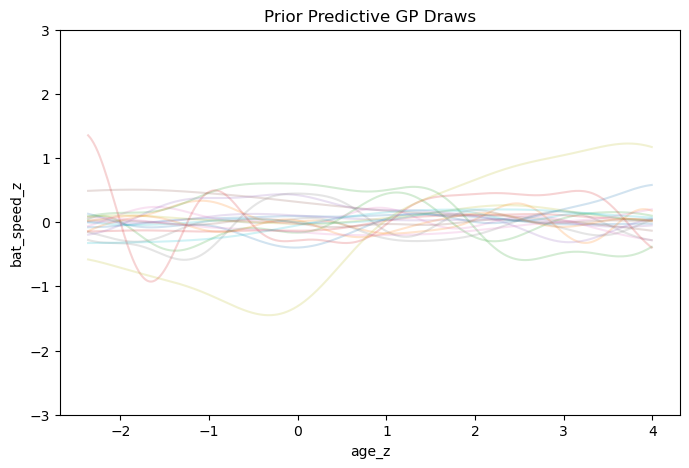

In [13]:
# prior predictve checks
samps = 20
with model:
    prior_samples = pm.sample_prior_predictive(samples=samps, var_names=["eta", "ls", "f"], random_seed=RANDOM_SEED)

# gp draws directly from HSGP
gp_draws = prior_samples.prior["f"].values.reshape(-1, len(age_z))
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    sort_idx = np.argsort(age_z)
    plt.plot(age_z[sort_idx], draw[sort_idx], alpha=0.2)
plt.ylim(-3, 3)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

In [14]:
# sample
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.95,  path='gp_constant.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [15]:
az.summary(trace, var_names=['f_hsgp_coeffs', 'eta', 'ls','mu_pop', 'sigma_pop'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
f_hsgp_coeffs[0],-0.156,0.955,-1.779,1.764,0.013,0.018,5709.0,3088.0,1.0
f_hsgp_coeffs[1],-0.225,1.007,-2.155,1.654,0.019,0.014,2865.0,2901.0,1.0
f_hsgp_coeffs[2],0.124,0.849,-1.398,1.826,0.013,0.013,4450.0,3328.0,1.0
f_hsgp_coeffs[3],0.555,0.929,-1.097,2.330,0.014,0.014,4467.0,3134.0,1.0
f_hsgp_coeffs[4],0.060,0.845,-1.553,1.624,0.013,0.013,4061.0,2894.0,1.0
f_hsgp_coeffs[5],-0.794,0.881,-2.504,0.786,0.013,0.013,4360.0,3250.0,1.0
f_hsgp_coeffs[6],-0.372,0.859,-2.027,1.188,0.014,0.014,3936.0,2857.0,1.0
f_hsgp_coeffs[7],0.814,0.881,-0.836,2.482,0.014,0.014,4008.0,2935.0,1.0
f_hsgp_coeffs[8],0.630,0.889,-1.122,2.244,0.013,0.013,4463.0,2933.0,1.0
f_hsgp_coeffs[9],-0.642,0.887,-2.291,0.998,0.015,0.014,3425.0,2701.0,1.0


In [16]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


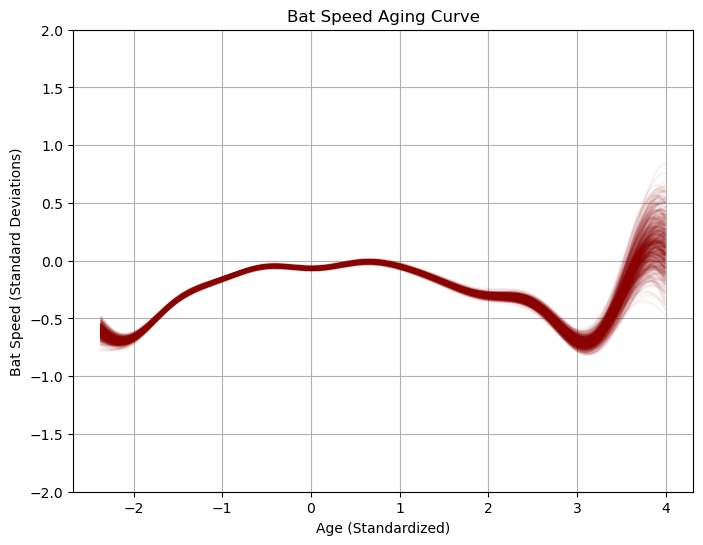

In [ ]:
# plot of aging curve
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = mu_pop + f
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title("Bat Speed Aging Curve")
ax.set_xlabel("Age (Standardized)")
ax.set_ylabel("Bat Speed (Standard Deviations)")
ax.set_ylim(-2, 2)
ax.grid(True)

In [18]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# with inverse gamma prior
# pymc model
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_index_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=2.0)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    target = pm.Normal("target", mu=theta, sigma=sigma_data, observed=bat_speed_z)

In [19]:
# sample
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.95,  path='gp_constant.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [20]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


In [ ]:
az.summary(trace, var_names=['f_hsgp_coeffs', 'eta', 'ls','mu_pop', 'sigma_pop'])
# very small length scale (ls)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
f_hsgp_coeffs[0],-0.168,0.958,-1.833,1.810,0.016,0.016,3681.0,2648.0,1.0
f_hsgp_coeffs[1],-0.179,1.018,-2.135,1.692,0.022,0.015,2173.0,2549.0,1.0
f_hsgp_coeffs[2],0.122,0.847,-1.607,1.621,0.016,0.013,2907.0,2568.0,1.0
f_hsgp_coeffs[3],0.466,0.932,-1.281,2.143,0.017,0.013,2877.0,2749.0,1.0
f_hsgp_coeffs[4],0.040,0.850,-1.691,1.536,0.017,0.013,2489.0,2340.0,1.0
f_hsgp_coeffs[5],-0.625,0.877,-2.340,0.971,0.016,0.013,3007.0,2597.0,1.0
f_hsgp_coeffs[6],-0.300,0.858,-1.961,1.278,0.017,0.013,2478.0,2711.0,1.0
f_hsgp_coeffs[7],0.620,0.879,-1.103,2.154,0.018,0.013,2307.0,2505.0,1.0
f_hsgp_coeffs[8],0.520,0.884,-1.128,2.167,0.017,0.013,2683.0,2617.0,1.0
f_hsgp_coeffs[9],-0.453,0.881,-2.064,1.259,0.019,0.013,2097.0,2521.0,1.0


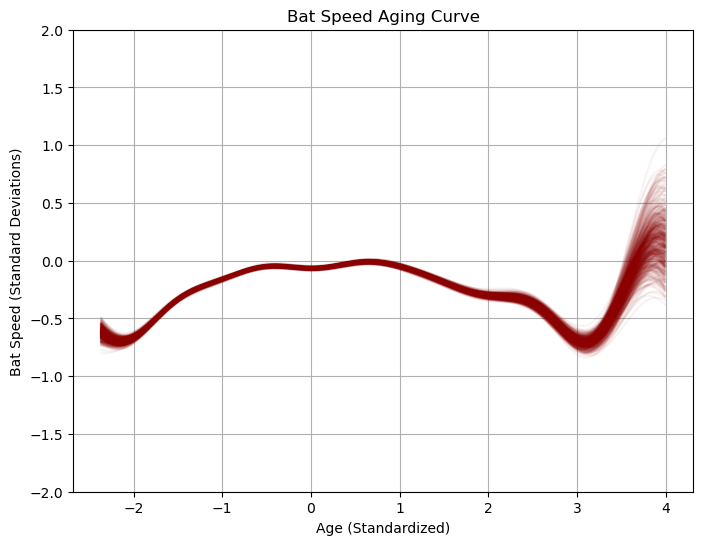

In [22]:
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = f + mu_pop
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title("Bat Speed Aging Curve")
ax.set_xlabel("Age (Standardized)")
ax.set_ylabel("Bat Speed (Standard Deviations)")
ax.set_ylim(-2, 2)
ax.grid(True)

In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# matern52 with Student T
# pymc model
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_index_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=2.0)
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    nu = pm.Exponential("nu", 1.0)
    target = pm.StudentT("target", nu=nu, mu=theta, sigma=sigma_data, observed=bat_speed_z)

In [ ]:
# sample
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.95,  path='gp_student.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]
# does not sample

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_player[Wyatt Langford (694671)],1.089,0.197,0.845,1.400,0.019,0.003,164.0,1521.0,1.02
mu_player[Matt Shaw (807713)],-0.418,0.228,-0.898,-0.175,0.023,0.013,176.0,815.0,1.02


In [47]:
az.summary(trace, var_names=[ 'eta', 'ls','mu_pop', 'sigma_pop'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.432,0.186,0.162,0.786,0.005,0.004,1508.0,2515.0,1.00
ls,1.861,0.618,0.813,3.029,0.018,0.011,1134.0,1962.0,1.01
mu_pop,-0.466,0.195,-0.861,-0.133,0.005,0.004,1423.0,1829.0,1.00
sigma_pop,0.926,0.021,0.887,0.964,0.000,0.000,2248.0,2996.0,1.00


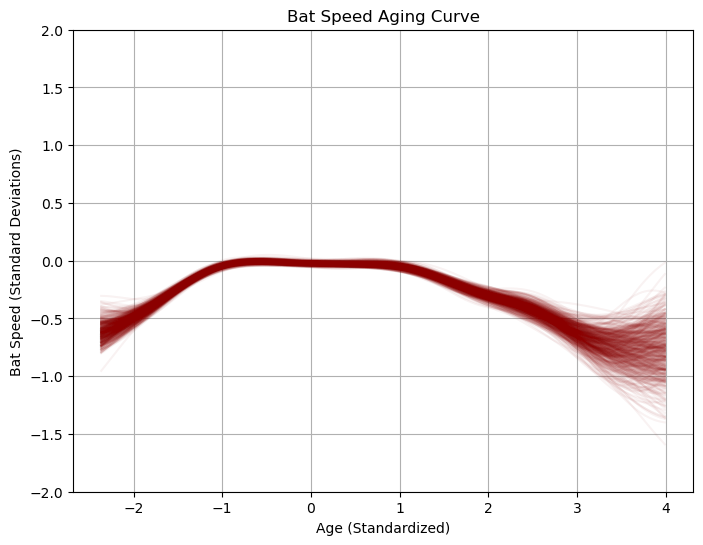

In [ ]:
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = f + mu_pop
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title("Bat Speed Aging Curve")
ax.set_xlabel("Age (Standardized)")
ax.set_ylabel("Bat Speed (Standard Deviations)")
ax.set_ylim(-2, 2)
ax.grid(True)

# better, smoother aging curve due to lengthscale

In [ ]:
# change the priors
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

# with different m and c params
with pm.Model(coords=coords) as model:
    # data
    player_idx = pm.Data("player_idx", player_index_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_z.reshape(-1,1))
    sigma_data = pm.Data('sigma_data', bat_speed_sigma)

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=0, sigma=1.0)
    sigma_pop = pm.Exponential("sigma_pop", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_pop, dims=("player",))

    # mean priors
    mean = pm.gp.mean.Zero()
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=3.0, beta=2.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp = pm.gp.HSGP(m=[25], c=2, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    nu = pm.Exponential("nu", 1.0)
    target = pm.StudentT("target", nu=nu, mu=theta, sigma=sigma_data, observed=bat_speed_z)

In [67]:
# sample
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.95,  path='gp_student.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [68]:
trace_df = az.summary(trace, hdi_prob=0.95)
trace_df.loc[trace_df['r_hat']>1.01]

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_player_z[Donovan Solano (456781)],-0.945,0.079,-1.100,-0.792,0.007,0.003,139.0,355.0,1.02
mu_player_z[Andrew McCutchen (457705)],0.675,0.067,0.549,0.809,0.004,0.001,229.0,799.0,1.02
mu_player_z[Paul Goldschmidt (502671)],0.986,0.064,0.864,1.114,0.004,0.001,236.0,724.0,1.02
mu_player_z[Freddie Freeman (518692)],-0.132,0.060,-0.257,-0.025,0.005,0.002,153.0,533.0,1.02
mu_player_z[Giancarlo Stanton (519317)],3.859,0.109,3.645,4.073,0.010,0.005,132.0,235.0,1.02
...,...,...,...,...,...,...,...,...,...
mu_player_z[Masataka Yoshida (807799)],0.078,0.060,-0.046,0.192,0.005,0.001,175.0,439.0,1.02
mu_player_z[Jung Hoo Lee (808982)],-1.000,0.061,-1.122,-0.878,0.006,0.003,101.0,142.0,1.02
sigma_pop,0.926,0.024,0.882,0.974,0.003,0.001,85.0,170.0,1.02
mu_player[Rafael Devers (646240)],0.276,0.139,0.125,0.694,0.021,0.036,161.0,41.0,1.03


In [64]:
az.summary(trace, var_names=[ 'eta','ls','mu_pop', 'sigma_pop'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta,0.376,0.145,0.153,0.638,0.004,0.003,1317.0,2071.0,1.00
ls,1.032,0.183,0.688,1.362,0.007,0.004,730.0,1201.0,1.00
mu_pop,-0.348,0.071,-0.486,-0.222,0.002,0.001,1293.0,2032.0,1.01
sigma_pop,0.927,0.021,0.886,0.966,0.000,0.000,2948.0,2577.0,1.00


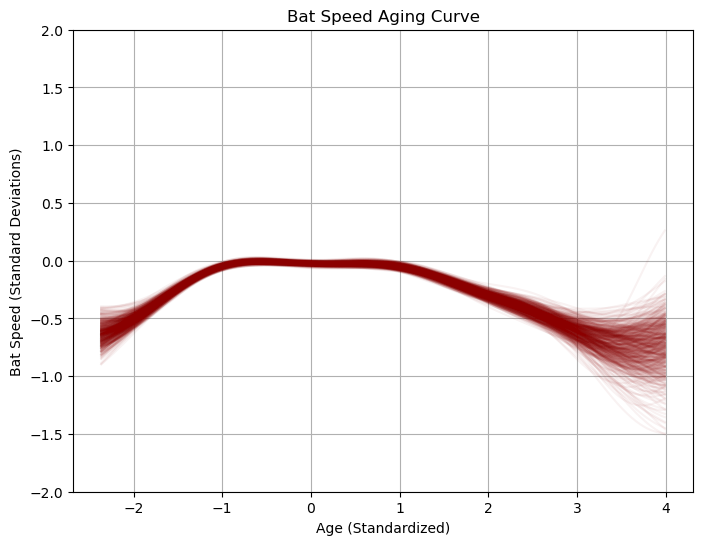

In [65]:
f_draws = trace.posterior["f"].values
mu_pop_draws = trace.posterior["mu_pop"].values
f = f_draws.reshape(-1, f_draws.shape[-1])
mu_pop = mu_pop_draws.reshape(-1, 1)

curves = f + mu_pop
sort_idx = np.argsort(age_z)
age_sorted = age_z[sort_idx]
curves_sorted = curves[:, sort_idx]

fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(RANDOM_SEED)
subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
for idx in subset_indices:
    ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

ax.set_title("Bat Speed Aging Curve")
ax.set_xlabel("Age (Standardized)")
ax.set_ylabel("Bat Speed (Standard Deviations)")
ax.set_ylim(-2, 2)
ax.grid(True)

In [ ]:
# STOP HERE

In [ ]:
# with linear mean
age_stack = np.column_stack([train_age_sq, train_age])

# pymc model
with pm.Model() as model:
    # data
    age_stack_data = pm.Data('age_stack_data', age_stack)
    sigma_data = pm.Data('sigma_data', train_bat_speed_std_z)

    # priors
    intercept = pm.Normal("intercept", mu=-0.001, sigma=0.001)
    coefs = pm.Normal("coefs", mu=-0.03, sigma=0.01)
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=intercept)

    # GP priors
    eta =pm.HalfNormal("eta", sigma=1.0)
    ls = pm.Gamma("ls", alpha=5.0, beta=1.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)

    # expected value
    theta = age_stack_data

    # likelihood, need to figure out m and L a bit more
    gp = pm.gp.HSGP(m=[30], L=[10.0], mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=theta)
    target = pm.Normal("target", mu=pt.flatten(f), sigma=sigma_data, observed=train_bat_speed_z)

In [ ]:
# with quadratic mean
age_stack = np.column_stack([train_age_sq, train_age])

# pymc model
with pm.Model() as model:
    # data
    age_stack_data = pm.Data('age_stack_data', age_stack)
    sigma_data = pm.Data('sigma_data', train_bat_speed_std_z)

    # priors
    b = pm.Normal("b", mu=-0.125, sigma=0.05)
    a = pm.Normal("a", mu=-0.02, sigma=0.01)
    coefs = pt.stack([a, b])[:, None]
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0.0)

    # GP priors
    eta =pm.HalfNormal("eta", sigma=1.0)
    ls = pm.Gamma("ls", alpha=5.0, beta=1.0)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=2, ls=ls, active_dims=[1])

    # expected value
    theta = age_stack_data

    # likelihood, need to figure out m and L a bit more
    gp = pm.gp.HSGP(m=[30], L=[10.0], mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=theta)
    target = pm.Normal("target", mu=pt.flatten(f), sigma=sigma_data, observed=train_bat_speed_z)

Text(0.5, 1.0, 'Prior Predictive GP Draws')

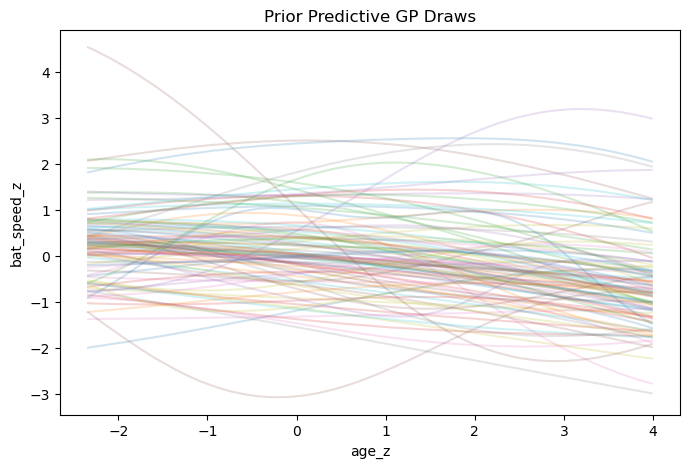

In [68]:
# by hand
gp_draws = []
a_draws = prior_samples.prior["a"].values.flatten()
b_draws = prior_samples.prior["b"].values.flatten()

eta_draws = prior_samples.prior["eta"].values.flatten()
ls_draws = prior_samples.prior["ls"].values.flatten()

age_list = np.linspace(train_age.min(), train_age.max(), 100)
age_grid = np.column_stack([age_list**2, age_list])

for a_i, b_i, eta_i, ls_i in zip(
    a_draws,
    b_draws,
    eta_draws,
    ls_draws
):
    # mean
    m = a_i * age_grid[:, 0] + b_i * age_grid[:, 1] + 0

    # covar
    K = eta_i**2 * np.exp(-0.5 * (age_grid[:, 1][:, None] - age_grid[:, 1][None, :])**2 / ls_i**2)
    K += 1e-6 * np.eye(len(age_grid))
    f = np.random.multivariate_normal(m, K)
    gp_draws.append(f)

gp_draws = np.asarray(gp_draws)

# plot gp draws by hand
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    plt.plot(age_list, draw, alpha=0.2)

plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

Text(0.5, 1.0, 'Prior Predictive GP Draws')

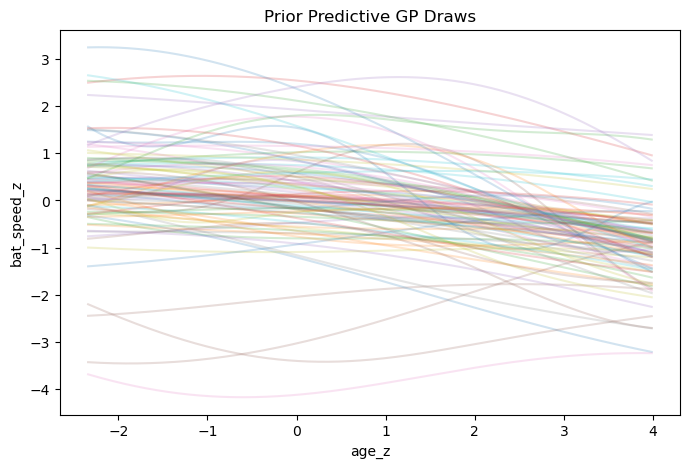

In [69]:
# gp draws directly from HSGP
gp_draws = prior_samples.prior["f"].values.reshape(-1, len(train_age))
plt.figure(figsize=(8, 5))
for draw in gp_draws:
    sort_idx = np.argsort(train_age)
    plt.plot(train_age[sort_idx], draw[sort_idx], alpha=0.2)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive GP Draws")

Text(0.5, 1.0, 'Prior Predictive Quad Curves')

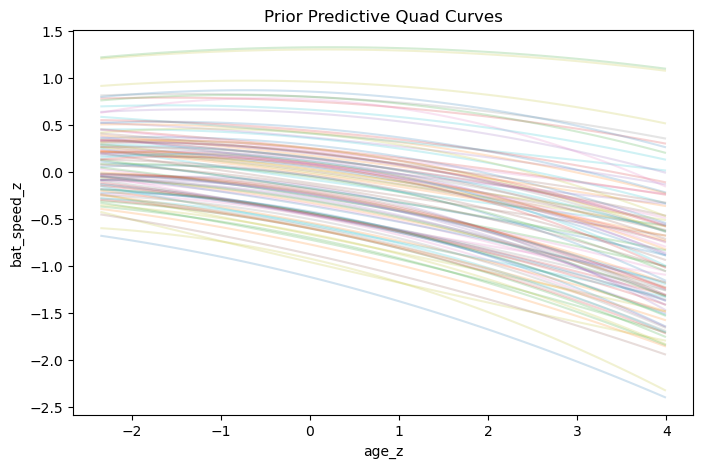

In [70]:
# plot of jsut the coefs
plt.figure(figsize=(8, 5))
for a_i, b_i, c_i in zip(a_draws, b_draws, c_draws):
    m = a_i * age_list**2 + b_i * age_list + c_i
    plt.plot(age_list, m, alpha=0.2)
plt.xlabel("age_z")
plt.ylabel("bat_speed_z")
plt.title("Prior Predictive Quad Curves")